# Señales y Sistemas
## Trabajo Práctico Nro. 1


---

### Grupo 10, 2Q2026
Integrantes:
* Ana Negre
* Juan José Medina




In [524]:
pip install numpy matplotlib wget scipy control schemdraw --quiet


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Modelado de señales continuas


### Señales base

Se modelan las señales de escalón, pulso, rampa, aleatoria y senoidal.

Si bien las señales graficadas no son verdaderamente continuas en el sentido matemático, se toma como paso $0.001$ en el rango de $-10$ a $10$; esto resulta en $20000$ puntos para las señales graficadas, lo cual se considera que aporta suficiente granularidad para el análisis realizado.


In [525]:
import numpy as np
import matplotlib.pyplot as plt

step = 0.001
t = np.arange(-10,10,step)
print("Cantidad de puntos:" + str(t.size))
seed = 30 # para reproducibilidad en señal aleatoria

Cantidad de puntos:20000


- Escalón

$$u(t)= \begin{cases}
0\space \text{si}\space t<0 \\
\frac{1}{2} \space \text{si}\space t=0\\
1\space\text{si}\space t>0\end{cases}$$


Text(0, 0.5, 'u(t)')

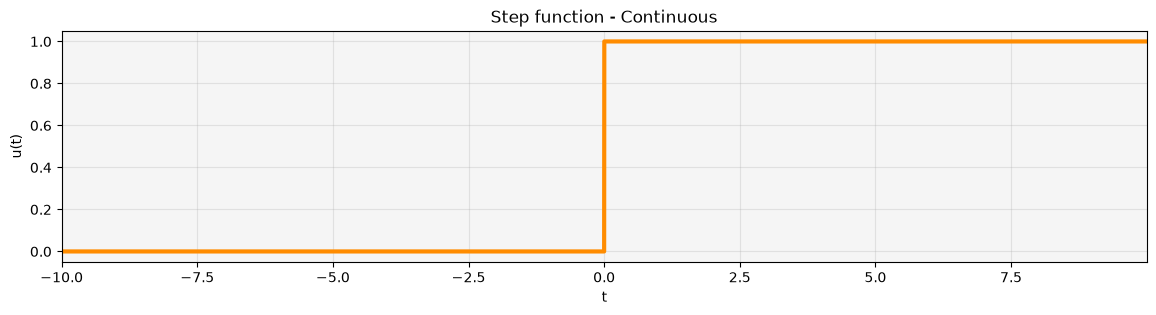

In [526]:
def u(t):
    return np.where(t >= 0, 1, 0)

fig = plt.figure(figsize=(14, 3), facecolor='white')
ax = plt.gca()
ax.set_facecolor('whitesmoke')

escalon_output = u(t)
plt.plot(t, escalon_output, linewidth=3, color="darkorange")
plt.xlim(t.min(), t.max())
plt.grid(True, alpha=0.3)

plt.title('Step function - Continuous')
plt.xlabel('t')
plt.ylabel('u(t)')
# plt.show()


- Pulso cuadrado
$$\Pi(t)=\begin{cases}1\space\text{si}\space|t|<\frac{1}{2}\\
\frac{1}{2}\space\text{si}\space t=\frac{1}{2}\\
0\space\text{si}\space |t|>\frac{1}{2}\end{cases}
$$

Text(0, 0.5, '$\\Pi(t)$')

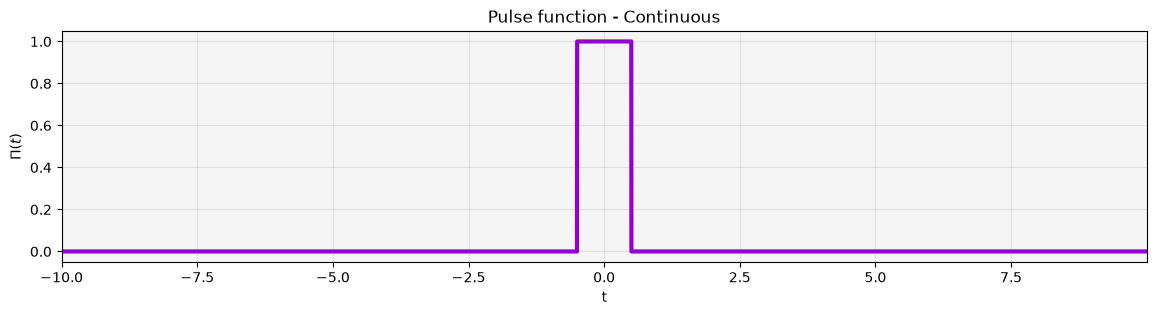

In [527]:
def pulse(t, T=1):
    return np.where(np.abs(t) <= T/2, 1, 0)


fig = plt.figure(figsize=(14, 3), facecolor='white')
ax = plt.gca()
ax.set_facecolor('whitesmoke')

pulso_resultado = pulse(t)
plt.plot(t, pulso_resultado, linewidth=3, color="darkviolet")
plt.xlim(t.min(), t.max())
plt.grid(True, alpha=0.3)

plt.title('Pulse function - Continuous')
plt.xlabel('t')
plt.ylabel(r"$\Pi(t)$")
# plt.show()

- Señal rampa
$$r(t)=\begin{cases}0\space\text{si}t<0\\t \space\text{si}\space t\geq 0\end{cases}$$

Text(0, 0.5, 'r(t)')

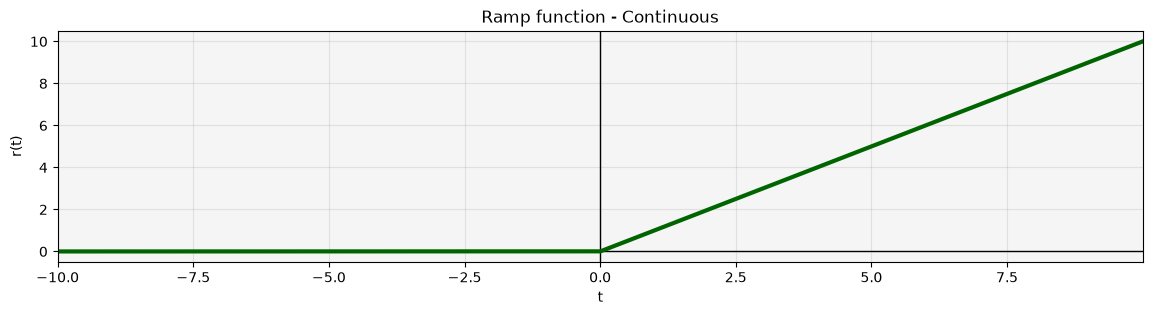

In [528]:
def ramp(t):
    return np.where(t > 0, t, 0)


fig = plt.figure(figsize=(14, 3), facecolor='white')
ax = plt.gca()
ax.set_facecolor('whitesmoke')
ax.axhline(0, color='black', linewidth=1)
ax.axvline(0, color='black', linewidth=1)
rampa_resultado=ramp(t)
plt.plot(t, rampa_resultado, linewidth=3, color="darkgreen")
plt.xlim(t.min(), t.max())
plt.grid(True, alpha=0.3)

plt.title('Ramp function - Continuous')
plt.xlabel('t')
plt.ylabel("r(t)")
# plt.show()


- Señal senoidal
$$sin(t)=A cos(2\pi f_0 t+\phi)$$

Donde $A$ es la amplitud, $f_0$ la frecuencia y $\phi$ la fase de la señal.

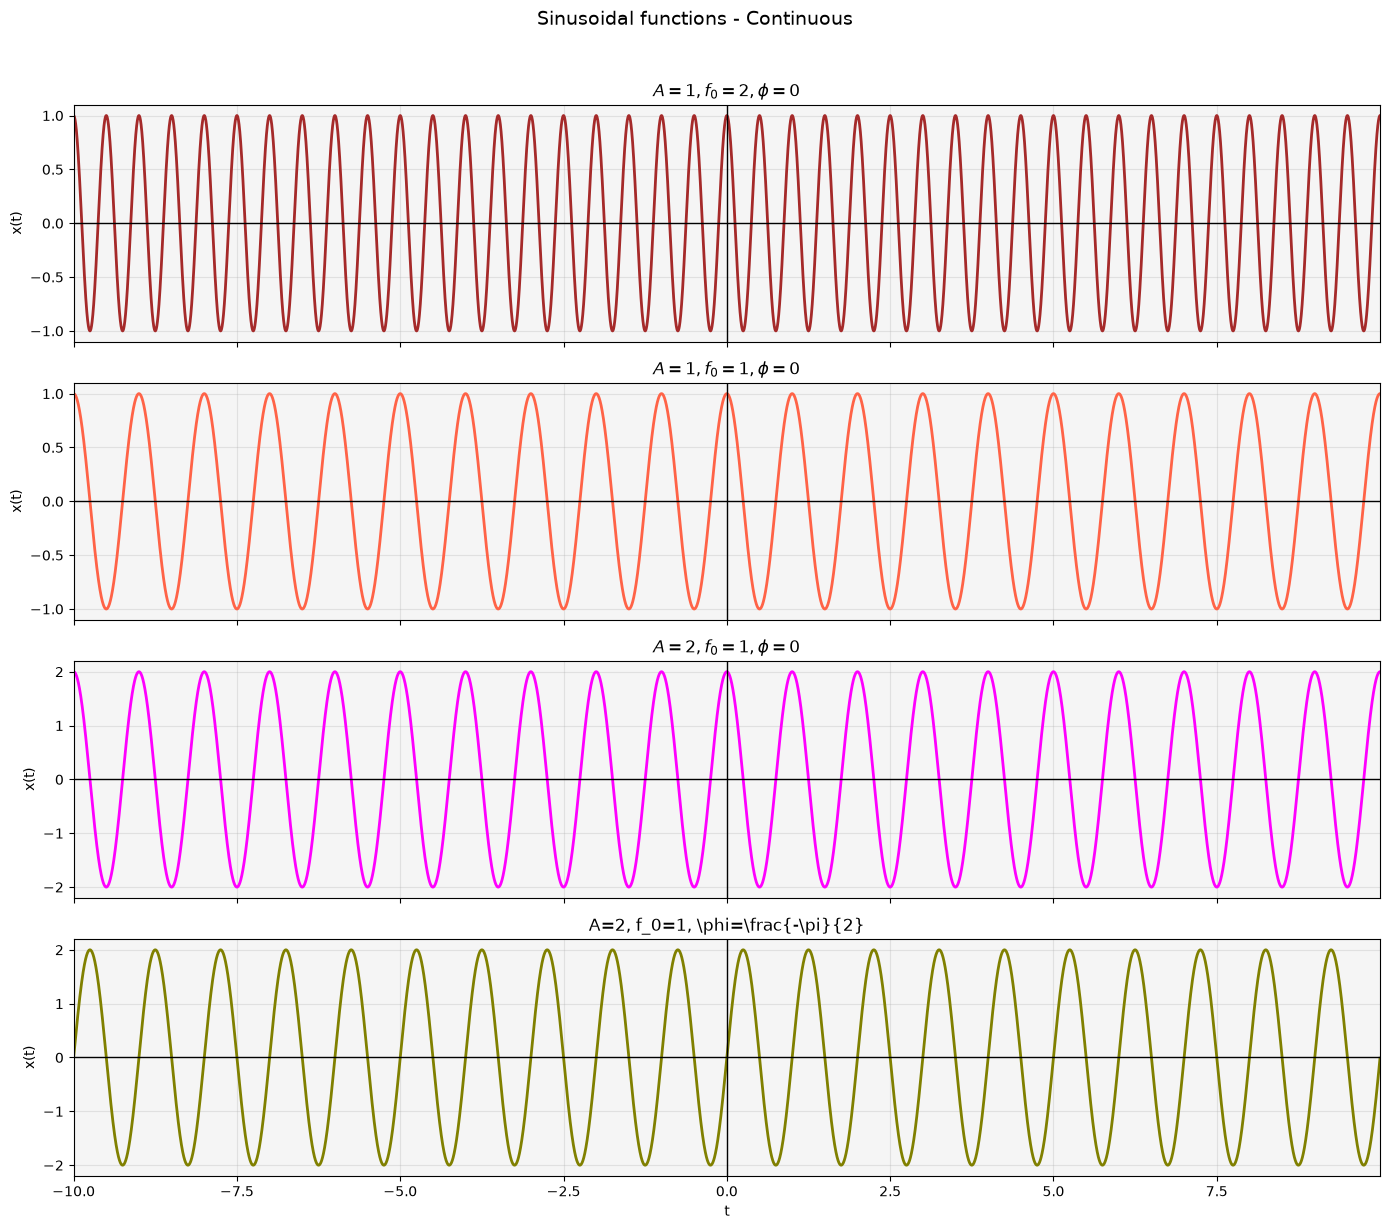

In [529]:
## Se modelan distintas amplitudes y frecuencias para ilustrar las diferencias entre ellas
PHASE = 0
AMPLITUDE = 1
FREQUENCY = 1

def sin(t, amplitude=AMPLITUDE, frequency=FREQUENCY, phase=PHASE):
    return amplitude * np.cos(2 * np.pi * frequency * t + phase)

señales = [
    dict(amplitude=1, frequency=2, phase=0, color="brown", label=r"$A=1, f_0=2, \phi=0$"),
    dict(amplitude=1, frequency=1, phase=0, color="tomato", label=r"$A=1, f_0=1, \phi=0$"),
    dict(amplitude=2, frequency=1, phase=0, color="magenta", label=r"$A=2, f_0=1, \phi=0$"),
    dict(amplitude=2, frequency=1, phase=-np.pi/2, color="olive", label=r"A=2, f_0=1, \phi=\frac{-\pi}{2}"),
]

fig, axes = plt.subplots(4, 1, figsize=(14, 12), facecolor='white', sharex=True)

for ax, s in zip(axes, señales):
    ax.set_facecolor('whitesmoke')
    ax.plot(t, sin(t, amplitude=s['amplitude'], frequency=s['frequency'], phase=s['phase']),
            linewidth=2, color=s['color'])
    ax.axhline(0, color='black', linewidth=1)
    ax.axvline(0, color='black', linewidth=1)
    ax.set_xlim(t.min(), t.max())
    ax.grid(True, alpha=0.3)
    ax.set_title(s['label'])
    ax.set_ylabel("x(t)")

axes[-1].set_xlabel('t')
fig.suptitle('Sinusoidal functions - Continuous', fontsize=14, y=1.02)
plt.tight_layout()
# plt.show()



- Señal aleatoria

En este caso, se toman los valores a partir de una distribución uniforme.
$$x(t) \sim \mathcal{U}(-k, k), \quad \forall t,k\in\Re $$


Text(0, 0.5, 'x(t)')

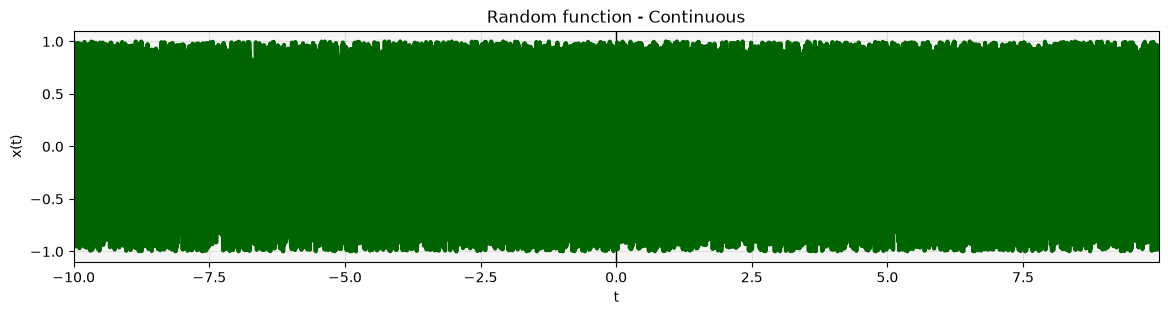

In [530]:
np.random.seed(seed)
k = 1

def random(t,k=1):
    return np.random.uniform(-k, k, len(t))

fig = plt.figure(figsize=(14, 3), facecolor='white')
ax = plt.gca()
ax.set_facecolor('whitesmoke')
ax.axhline(0, color='black', linewidth=1)
ax.axvline(0, color='black', linewidth=1)
random_resultados = random(t)
plt.plot(t, random_resultados, linewidth=3, color="darkgreen")
plt.xlim(t.min(), t.max())
plt.grid(True, alpha=0.3)

plt.title('Random function - Continuous')
plt.xlabel('t')
plt.ylabel("x(t)")
# plt.show()

### Señales reales

Se grafican señales reales de electrocardiograma (ECG) y fonocardiograma (PCG).

[Fuente: Pshysio.net](https://physionet.org/content/ephnogram/1.0.0/MAT/#files-panel)

#### Obtención de archivos
Primero se descargan los archivos deseados utilizando la utility `wget`.
Los archivos se encuentran nombrados del 1 al 69 como `ECGPCG00XX.mat`:

```bash
wget -r -N -c -np https://physionet.org/files/ephnogram/1.0.0/MAT/ECGPCG0010.mat #ejemplo
```

In [531]:
import os

URL = "https://physionet.org/files/ephnogram/1.0.0/MAT/"
FILE = "ECGPCG0010.mat"  # from 00 to 69

target_dir = "/Users/anegre/Documents/ITBA-docs/SeñalesYSistemas/TP1-SeñalesYSistemas-16.68/data/"
os.makedirs(target_dir, exist_ok=True)

filepath = os.path.join(target_dir, FILE)

if not os.path.exists(filepath):
    !wget --no-check-certificate -P {target_dir} {URL}{FILE}

In [532]:
from scipy.io import loadmat

data = loadmat(os.path.join(target_dir, FILE))
print(data.keys())
ecg = data['ECG'].flatten()
pcg = data['PCG'].flatten()
fs = int(data['fs'].flatten()[0])

print(f"ECG length: {len(ecg)}, sampling rate: {fs} Hz")
print(f"ECG duration: {len(ecg)/fs:.1f} seconds")

print(f"PCG length: {len(pcg)}, sampling rate: {fs} Hz")
print(f"PCG duration: {len(pcg)/fs:.1f} seconds")


dict_keys(['__header__', '__version__', '__globals__', 'ECG', 'PCG', 'fs'])
ECG length: 14400000, sampling rate: 8000 Hz
ECG duration: 1800.0 seconds
PCG length: 14400000, sampling rate: 8000 Hz
PCG duration: 1800.0 seconds


#### Gráficos de PCG y ECG
A continuación se grafican las señales correspondientes al ECG y PCG:

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle, ConnectionPatch

t = np.arange(len(ecg)) / fs
window = slice(0, int(fs * 18))
window_zoom = slice(int(fs * 2), int(fs * 4))  # subset de 2s



fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8), facecolor='white')

# grafico completo
ax1.set_facecolor('whitesmoke')
ax1.plot(t[window], pcg[window], linewidth=1, color="firebrick")
ax1.set_xlim(t[window].min(), t[window].max())
ax1.grid(True, alpha=0.3)
ax1.set_title('ECG')
ax1.set_xlabel('t (s)')
ax1.set_ylabel("x(t)")

# rectángulo para ver el zoom in
t_zoom_start = t[window_zoom].min()
t_zoom_end = t[window_zoom].max()
y_min, y_max = pcg[window].min(), pcg[window].max()
rect = Rectangle(
    (t_zoom_start, y_min), t_zoom_end - t_zoom_start, y_max - y_min,
    linewidth=1.5, edgecolor='steelblue', facecolor='none', linestyle='-.'
)
ax1.add_patch(rect)

# grafico zoom
ax2.set_facecolor('whitesmoke')
ax2.plot(t[window_zoom], pcg[window_zoom], linewidth=2, color="firebrick")
ax2.set_xlim(t[window_zoom].min(), t[window_zoom].max())
ax2.grid(True, alpha=0.3)
ax2.set_title('ECG - Zoom (2-4s)')
ax2.set_xlabel('t (s)')
ax2.set_ylabel("x(t)")
y_zoom_min, y_zoom_max = pcg[window_zoom].min(), pcg[window_zoom].max()

# conectores
con1 = ConnectionPatch(
    xyA=(t_zoom_start, y_min), coordsA=ax1.transData,
    xyB=(0, 1), coordsB=ax2.transAxes,
    color='steelblue', linestyle='--', linewidth=1
)

con2 = ConnectionPatch(
    xyA=(t_zoom_end, y_min), coordsA=ax1.transData,
    xyB=(1, 1), coordsB=ax2.transAxes,
    color='steelblue', linestyle='--', linewidth=1
)
fig.add_artist(con1)
fig.add_artist(con2)


plt.tight_layout()
# plt.show()

In [ ]:
# @title
from matplotlib.patches import Rectangle, ConnectionPatch

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8), facecolor='white')

# grafico completo
ax1.set_facecolor('whitesmoke')
ax1.plot(t[window], pcg[window], linewidth=1, color="limegreen")
ax1.set_xlim(t[window].min(), t[window].max())
ax1.grid(True, alpha=0.3)
ax1.set_title('PCG')
ax1.set_xlabel('t (s)')
ax1.set_ylabel("x(t)")

# rectángulo para ver el zoom in
t_zoom_start = t[window_zoom].min()
t_zoom_end = t[window_zoom].max()
y_min, y_max = pcg[window].min(), pcg[window].max()
rect = Rectangle(
    (t_zoom_start, y_min), t_zoom_end - t_zoom_start, y_max - y_min,
    linewidth=1.5, edgecolor='steelblue', facecolor='none', linestyle='-.'
)
ax1.add_patch(rect)

# grafico zoom
ax2.set_facecolor('whitesmoke')
ax2.plot(t[window_zoom], pcg[window_zoom], linewidth=2, color="limegreen")
ax2.set_xlim(t[window_zoom].min(), t[window_zoom].max())
ax2.grid(True, alpha=0.3)
ax2.set_title('PCG - Zoom (2-4s)')
ax2.set_xlabel('t (s)')
ax2.set_ylabel("x(t)")
y_zoom_min, y_zoom_max = pcg[window_zoom].min(), pcg[window_zoom].max()

# conectores
con1 = ConnectionPatch(
    xyA=(t_zoom_start, y_min), coordsA=ax1.transData,
    xyB=(0, 1), coordsB=ax2.transAxes,
    color='steelblue', linestyle='--', linewidth=1
)

con2 = ConnectionPatch(
    xyA=(t_zoom_end, y_min), coordsA=ax1.transData,
    xyB=(1, 1), coordsB=ax2.transAxes,
    color='steelblue', linestyle='--', linewidth=1
)
fig.add_artist(con1)
fig.add_artist(con2)


plt.tight_layout()
# plt.show()

## Modelado de señales discretas
A continuación se modelan las señales previamente visualizadas mediante _muestreo periódico_.
Para esto se utiliza el modelo de conversor A/D visto en clase:

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle, FancyArrowPatch

t = np.arange(-10,10,step)
T = 1/20            # período de muestreo
fs_dis = 1/T
n = np.arange(0, int(1/T))           # índice discreto n
t_n = n*T                            # instantes nT

In [ ]:
# visualizador del modelo porque no hay lib de latex nativa..

fig, ax = plt.subplots(figsize=(9, 3.5))

# --- Multiplicador (círculo con x) ---
mult_center = (2.5, 1.5)
mult = Circle(mult_center, 0.35, fill=False, lw=1.3)
ax.add_patch(mult)
ax.text(*mult_center, r'$\times$', ha='center', va='center', fontsize=14)

# --- Caja del conversor ---
conv_xy = (4.2, 0.8)
conv_w, conv_h = 3.0, 1.4
conv = Rectangle(conv_xy, conv_w, conv_h, fill=False, lw=1.3)
ax.add_patch(conv)
ax.text(conv_xy[0]+conv_w/2, conv_xy[1]+conv_h/2,
        "Conversor de tren de\nimpulsos a secuencia\nde tiempo discreto",
        ha='center', va='center', fontsize=9)

# --- Flechas ---
def arrow(p1, p2):
    ax.add_patch(FancyArrowPatch(p1, p2, arrowstyle='-|>', mutation_scale=15, lw=1.2, color='black'))

arrow((0.3, 1.5), (mult_center[0]-0.35, 1.5))                     # x_c(t) -> mult
arrow((mult_center[0], 2.6), (mult_center[0], mult_center[1]+0.35))  # p(t) -> mult
arrow((mult_center[0]+0.35, 1.5), conv_xy)                        # mult -> conv (aprox)
arrow((mult_center[0]+0.35, 1.5), (conv_xy[0], conv_xy[1]+conv_h/2))  # x_p(t) -> conv
arrow((conv_xy[0]+conv_w, conv_xy[1]+conv_h/2), (conv_xy[0]+conv_w+1.2, conv_xy[1]+conv_h/2))  # salida

# --- Etiquetas de señales -
ax.text(0.3, 1.7, r'$x_c(t)$', fontsize=11, va='bottom')
ax.text(mult_center[0], 2.75, r'$p(t)$', fontsize=11, ha='center', va='bottom')
ax.text((mult_center[0]+conv_xy[0])/2, conv_xy[1]+conv_h/2+0.15, r'$x_p(t)$', fontsize=11, ha='center')
ax.text(conv_xy[0]+conv_w+1.3, conv_xy[1]+conv_h/2+0.15, r'$x[n]=x_c(nT)$', fontsize=11, ha='left')

# --- Recuadro punteado
box = Rectangle((1.6, 0.3), 6.2, 2.6, fill=False, linestyle='--', lw=1.0)
ax.add_patch(box)
ax.text(1.6+6.2/2, 0.3+2.6+0.15, "Conversor A/D", fontsize=12, ha='center')

ax.set_xlim(0, 8.2)
ax.set_ylim(0, 3.3)
ax.axis('off')
plt.tight_layout()
plt.show()


Donde $p(t)$ es un tren de impulsos espaciados en $T$:
$$p(t)=\sum_{n\in \mathbb{Z}}\delta(t-nT)$$

In [ ]:
N = int(round(2 / step))
t_n = t[::N]
n = np.arange(len(t_n))

fig, ax = plt.subplots(figsize=(8,4))
ax.set_facecolor('whitesmoke')
ax.stem(t_n, np.ones_like(t_n), basefmt=" ")
ax.set_title(r'$p(t)$' + f'  (T={T})')
ax.set_xlabel('t [s]')
ax.set_ylim(0, 1.2)
ax.grid(True)


Para discretizar las señales, entonces, primero se parte de la señal en tiempo continuo (en este caso, definidas sobre el vector $t$, que "simula" un tiempo continuo mediante un paso fino $0.01$).
Luego se define un período de muestreo $T$, y se genera el tren de impulsos $p(t)$.
El resultado de la multiplicación:
$$x_p(t)=x_c(t)\cdot p(t)$$
Proviene de la propiedad de muestreo de la Delta de Dirac:
$$x_p(t)=\sum_n x_c(t)\delta(t-nT)=\sum x_c(nT)\delta (t-nT)$$
Finalmente se pasa a una secuencia de tiempo discreto tal que:
$$x[n]=x_c(nT)$$

Este proceso puede verse graficado para algunas de las señales previamente descritas:

In [ ]:
# auxiliar, graficar el proceso de muestreo
import numpy as np
import matplotlib.pyplot as plt


def plot_muestreo(x_c, t, T, titulo_senal=r'$x_c(t)$', figsize=(10, 9)):
    step = t[1] - t[0]
    N = int(round(T / step))

    t_n = t[::N]
    n = np.arange(len(t_n))
    xc_cont = x_c(t)
    xc_en_tn = xc_cont[::N]

    fig, axs = plt.subplots(4, 1, figsize=figsize)

    # señal cont
    axs[0].plot(t, xc_cont, color='C0')
    axs[0].set_title(titulo_senal)
    axs[0].set_xlabel('t [s]')
    axs[0].grid(True)

    # p(t)
    axs[1].stem(t_n, np.ones_like(t_n), basefmt=" ")
    axs[1].set_title(r'$p(t) = \sum_n \delta(t-nT)$' + f'  (T={T})')
    axs[1].set_xlabel('t [s]')
    axs[1].set_ylim(0, 1.2)
    axs[1].grid(True)

    # impulsos ponderados, tiempo continuo
    axs[2].plot(t, xc_cont, color='C0', alpha=0.25, label=r'$x_c(t)$ (ref.)')
    markerline, stemlines, baseline = axs[2].stem(t_n, xc_en_tn, basefmt=" ")
    plt.setp(markerline, color='C1')
    plt.setp(stemlines, color='C1')
    axs[2].set_title(r'$x_p(t) = x_c(t)\,p(t)$')
    axs[2].set_xlabel('t [s]')
    axs[2].legend(loc='upper right')
    axs[2].grid(True)

    # x[n], secuencia de tiempo discreto (eje n, no t)
    markerline, stemlines, baseline = axs[3].stem(n, xc_en_tn, basefmt=" ")
    plt.setp(markerline, color='C2')
    plt.setp(stemlines, color='C2')
    axs[3].set_title(r'$x[n] = x_c(nT)$')
    axs[3].set_xlabel('n')
    axs[3].grid(True)

    plt.tight_layout()
    return fig, axs, (n, t_n, xc_en_tn)

- Señales Senoidales

In [ ]:
fig, axs, (n, t_n, xn) = plot_muestreo(
    lambda t: sin(t, amplitude=2, frequency=0.5, phase=0),
    t, T=0.5,
    titulo_senal=r'$x_c(t)=2\cos(2\pi \cdot 0.5\, t)$'
)

- Pulso

In [ ]:
fig, axs, (n, t_n, xn) = plot_muestreo(
    pulse,
    t, T=0.5,
    titulo_senal=r'$x_c(t)=2\cos(2\pi \cdot 0.5\, t)$'
)

- Señal real

Se muestrea la señal obtenida del fonograma, observando que el período de muestreo de la señal está dado por la fuente: $\frac{1}{fs}=0.000125s$, por lo cual el período elegido de muestreo debe ser igual o superior al mismo.
Se elige $T=0.5$.


In [ ]:

T_muestreo_pcg = 0.5
t = np.arange(len(ecg)) / fs

def hacer_x_c_desde_array(t_data, x_data):
    def x_c(t_eval):
        return np.interp(t_eval, t_data, x_data)
    return x_c

x_c_pcg = hacer_x_c_desde_array(t, pcg)

fig, axs, (n, t_n, xn) = plot_muestreo(x_c_pcg, t, T=0.5, titulo_senal='PCG')

Cabe destacar que el volumen de datos dificulta la visualización de la señal completa, con lo cual se puede tomar una ventana, por ejemplo de $2-4s$.

In [ ]:
fs = 8000
t = np.arange(len(pcg)) / fs

window = slice(int(fs*2), int(fs*4))   # 2 a 4 segundos, igual que tu zoom de referencia
t_win = t[window]
pcg_win = pcg[window]

x_c_pcg_win = hacer_x_c_desde_array(t_win, pcg_win)
fig, axs, (n, t_n, xn) = plot_muestreo(x_c_pcg_win, t_win, T=0.05, titulo_senal='PCG (zoom 2-4s)')

## Comportamiento de circuito eléctrico
Se tiene un circuito RLC serie, donde: $L=330\mu H,R_1=4,7 Ω,C=33nF,R_C=56Ω$

In [ ]:
# circuito dibujado porque no me deja pegar imagenes.....
import schemdraw
import schemdraw.elements as elm

with schemdraw.Drawing() as d:
    d += (Vs := elm.SourceSin().up().label('$V_s$', loc='left'))
    d += elm.Line().right().length(0.5)
    d += (L := elm.Inductor().right().label('$L$', loc='top'))
    d += elm.Resistor().right().label('$R_1$', loc='top')
    d += elm.Capacitor().right().label('$C$', loc='top')
    d += (Rc := elm.Resistor().down().label('$R_c$', loc='right'))
    d += elm.Line().left().tox(Vs.start)
    d += elm.Line().up().endpoints(d.here, Vs.start)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Valores del circuito
L = 330e-6      # H
R1 = 4.7        # ohm
C = 33e-9       # F
Rc = 56         # ohm

### Modelo: Ecuación Diferencial

Para el circuito RLC se define como entrada y salida:

$$
x(t)=V_s(t),
\qquad
y(t)=V_{R_c}(t).
$$

Como todos los elementos se encuentran en serie, circula por ellos la misma corriente $i(t)$.
Aplicando la Ley de Kirchhoff de tensiones (KVL):

$$
V_s(t)=V_L(t)+V_{R_1}(t)+V_C(t)+V_{R_c}(t)
$$

Donde las tensiones de cada elemento son:

$$V_L(t)=L\frac{di(t)}{dt}$$
$$V_{R_1}(t)=R_1i(t)$$

$$V_C(t)=\frac{1}{C}\int_{-\infty}^{t}i(\tau)\,d\tau$$
$$V_{R_c}(t)=R_ci(t)=y(t).$$

Reescribiendo la ecuación en función de la entrada/salida, y teniendo en cuenta que $i(t)=\frac{y(t)}{R_c}$, se obtiene:

$$
x(t)=
L\frac{di(t)}{dt}
+(R_1+R_c)i(t)
+\frac{1}{C}\int_{-\infty}^{t}i(\tau)\,d\tau.
$$

$$
x(t)=
\frac{L}{R_c}\frac{dy(t)}{dt}
+\frac{R_1+R_c}{R_c}y(t)
+\frac{1}{R_cC}\int_{-\infty}^{t}y(\tau)\,d\tau.
$$

Finalmente, se puede derivar miembro a miembro respecto del tiempo para reescribir $V_C(t)$ en función de $y(t)$, y luego multiplicar por $R_C*C$:
$$x'(t)=\frac{L}{RC}y''(t)+\frac{R_1+R_C}{R_C}y'(t)+\frac{1}{R_CC}$$
$$
\boxed{
LCy''(t)
+(R_1+R_c)Cy'(t)
+y(t)
=R_cCx'(t)
}
$$

Esta es la ecuación diferencial que modela la relación entre la tensión de entrada
$V_s(t)$ y la tensión de salida sobre $R_c$. Adicionalmente, este sistema $S_c$ descrito por la ecuación diferencial de segundo orden es un sistema LTI.



### Función de transferencia

Por el otro lado, sabemos que, para un sistema LTI descrito por una ecuación diferencial de coficientes constantes y reales de la forma

$$\sum^{n}_{k=0}a_ky^{(k)}(t)=\sum^{m}_{l=0}b_ly^{(l)}(t),$$

la correspondiente función de transferencia, aplicando transformada de Laplace con condiciones iniciales nulas (se asume sistema relajado) está dada por:

$$H(s)=\frac{Y(s)}{X(s)}=\frac{\sum^m_{l=0}b_ls^l}{\sum^n_{k=0}a_ks^k}=\frac{N(s)}{D(s)}$$

En particular, para este circuito, la función de transferencia queda definida:

$$H(s)=\frac{R_cCs}{LCs^2+(R_1+R_c)Cs+1}$$


$$\boxed{H(s)=\frac{\frac{R_C}{C}s}{s^2+\frac{R_1+R_C}{L}+\frac{1}{LC}}}$$

Utilizando los valores concretos del circuito

$$
L=330\,\mu H,
\qquad
R_1=4.7\,\Omega,
\qquad
C=33\,nF,
\qquad
R_c=56\,\Omega,
$$

se obtiene una función de transferencia de segundo orden cuyo numerador contiene un
cero en $s=0$ y dos polos complejos conjugados.

Puede factorizarse de la forma:
$$G(s)=K\frac{\prod^R_{k=1}(s-\beta_k)}{\prod^P_{l=1}(s-\alpha_l)}$$
Para este sistema, se expresa como:
$$H(s)=\frac{R_C}{L}\frac{s}{(s-p_1)(s-p_2)},$$
$$p_{1,2}=-\frac{R_1+R_C}{2L}\mp \frac{1}{2L}\sqrt{(R_1+R_C)^2-\frac{4L}{C}} \Rightarrow p_{1,2}=-9,197\times 10^4 \mp j 2,888\times 10^5
$$
Como la parte real de los polos son _negativos_, los polos estarán en el semiplano izquierdo. Además, el sistema, al modelar un circuito físico real, es **causal**, por lo que su ROC es el semiplano derecho delimitado por el polo de mayor parte real. Como ambos polos tienen parte real negativa, dicha ROC incluye el eje
jω, y es por tanto _BIBO-estable_.

Dados los valores numéricos del problema, se pueden visualizar los polos y ceros del sistema:

In [ ]:
# H(s) = Rc*C*s / (L*C*s^2 + (R1+Rc)*C*s + 1)
num = [Rc*C, 0]
den = [L*C, (R1+Rc)*C, 1]

In [ ]:
import control as ct
ct.pzmap(ct.tf(num,den))

Observando los vectores de los polos/ceros a una frecuencia $w$ particular, vemos que a frecuencias  altas, el aporte de los vectores provenientes del denominador aportan el doble que el correspondiente al 0, con lo cual el módulo de $H(w)$ tenderá a 0.

De manera analítica se tiene que:
$$
H(0)=0,
\qquad
\lim_{f\to\infty}|H(j2\pi f)|=0,
$$

por lo que el circuito atenúa tanto las bajas como las altas frecuencias.

Podemos observar el comportamiento pasa banda en los gráficos de módulo y fase en función de $jw$:

In [ ]:
 # gráfico de función



w = np.linspace(-2e6, 2e6, 4000)
w, H = signal.freqs(num, den, worN=w)


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 5))
ax1.set_facecolor('whitesmoke')
ax1.axhline(0, color='black', linewidth=1)
ax1.axvline(0, color='black', linewidth=1)
ax2.set_facecolor('whitesmoke')
ax2.axhline(0, color='black', linewidth=1)
ax2.axvline(0, color='black', linewidth=1)
plt.xlim(w.min(), w.max())

ax1.plot(w, np.abs(H),color="mediumblue",linewidth=2.0)
ax1.set_ylabel(r"$|H(jw)|$")
ax1.grid(True)
ax1.set_title('Respuesta en frecuencia del circuito RLC') # se puede evaluar porque la ROC incluye iw

ax2.plot(w, np.angle(H, deg=False),color="mediumblue",linewidth=2.0)
ax2.set_ylabel(r"$\Phi(jw) (rad)$")
ax2.set_xlabel(r"$w (rad/s)$")
ax2.grid(True)

plt.tight_layout()
#

### Trazas de Bode

Por el otro lado, puede escribirse el sistema $H(s)$ de manera normalizada, evaluando los factores constantes, de primer y segundo orden de forma tal que el comportamiento resultante equivale a la composición los sistemas provenientes de estos factores.

Luego para un sistema de estas características, la factorización según el modelo será:

$$
H(s) = H_0(s)\times H_1(s)\times H_2(s)$$
$$
H(s) = K \times s \times \frac{w_n^2}{s^2+2w_n\zeta s+w_n^2}
$$

En particular:

$$
H(s)=R_C C \times s \times \frac {w_n^2}{s^2+2\zeta w_n s + w_n^2}
$$
$$
K=R_C C, \qquad w_n=\sqrt{\frac{1}{LC}},\qquad \zeta=\frac{R_1+R_C}{2}\sqrt{\frac{C}{L}}
$$

Numéricamente,
$$w_n\simeq 3,030 ×10^5 rad/s\Rightarrow f_n\simeq 48,2kHz$$
$$\zeta\simeq 0,304 < 1$$
$$K=1,848\times 10^{-6}$$

En este caso, $f_n$ es la frecuencia de resonancia, dado que al minimizar el cociente se obtiene $w_r=w_n$.
Además, hay un sobrepico en este punto de altura $|H(jw_n)|=M_r=0,923$

A partir de lo analizado, se pueden observar los aportes de los factores en el comportamiento final de $H(s)$ según las trazas de Bode:

In [ ]:
# H(s) = H0(s) * H1(s) * H2(s) = K * s * wn^2/(s^2+2*zeta*wn*s+wn^2)

L, R1, C, Rc = 330e-6, 4.7, 33e-9, 56.0

wn = np.sqrt(1 / (L * C))
zeta = (R1 + Rc) / 2 * np.sqrt(C / L)
K = Rc * C

#num = [Rc * C, 0]
#den = [L * C, (R1 + Rc) * C, 1]
H = signal.TransferFunction(num, den)

H0 = signal.TransferFunction([K], [1])
H1 = signal.TransferFunction([1, 0], [1])
H2 = signal.TransferFunction([wn ** 2], [1, 2 * zeta * wn, wn ** 2])

w = np.logspace(3, 7, 1000)

w, mag, phase = signal.bode(H, w)
_, mag0, phase0 = signal.bode(H0, w)
_, mag1, phase1 = signal.bode(H1, w)
_, mag2, phase2 = signal.bode(H2, w)

plt.figure(figsize=(9, 5.5))
ax = plt.gca()
ax.set_facecolor('whitesmoke')
ax.axhline(0, color='black', linewidth=1)
plt.semilogx(w, mag0, '--', label=r'$H_0(s)$ (ganancia)',linewidth=2.5)
plt.semilogx(w, mag1, '--', label=r'$H_1(s)$ (cero en origen)',linewidth=2.5)
plt.semilogx(w, mag2, '--', label=r'$H_2(s)$ (2do orden)',linewidth=2.5)
plt.semilogx(w, mag, color='k', lw=2.2, label=r'$H(s)$ completo')
plt.xlabel("w [rad/s]")
plt.ylabel("Magnitud [dB]")
plt.title("Diagrama de Bode - Modulo ")
plt.grid(True, which="both")
plt.legend()

# --- Bode: Fase ---
plt.figure(figsize=(9, 5.5))
ax = plt.gca()
ax.set_facecolor('whitesmoke')
ax.axhline(0, color='black', linewidth=1)
plt.semilogx(w, phase0, '--', label=r'$H_0(s)$',linewidth=2.5)
plt.semilogx(w, phase1, '--', label=r'$H_1(s)$',linewidth=2.5)
plt.semilogx(w, phase2, '--', label=r'$H_2(s)$',linewidth=2.5)
plt.semilogx(w, phase, color='k', lw=2.2, label=r'$H(s)$')
plt.xlabel("w [rad/s]")
plt.ylabel("Fase [°]")
plt.title("Diagrama de Bode - Fase")
plt.grid(True, which="both")
plt.legend()

plt.show()
#

### Interpretación del filtro

A partir del diagrama de Bode se observa que el circuito se comporta como un **filtro pasa-banda**. Las señales de baja frecuencia aparecen fuertemente atenuadas, luego la ganancia aumenta hasta alcanzar un máximo alrededor de la frecuencia de resonancia del circuito, cercana a:

$$
f_0 \approx 48\,\text{kHz}
$$

A partir de esa zona, la ganancia vuelve a disminuir para frecuencias más altas.

En consecuencia, si una señal de entrada contiene varias componentes frecuenciales, las cercanas a la banda de paso aparecerán con mayor amplitud en la salida que las que se encuentren alejadas de esa zona.

El gráfico de fase muestra además que el circuito introduce un desfase dependiente de la frecuencia: las componentes de baja frecuencia presentan una fase cercana a \(+90), alrededor de la frecuencia central el desfase pasa aproximadamente por \(0), y a frecuencias altas tiende a \(-90).

### Simulacion con espectro de entrada y salida

A continuación se observan las salidas filtradas a partir de las señales base graficadas anteriormente, y las señales reales de PCG y ECG.

Para analizar el comportamiento del circuito se estudian tanto la señal de entrada
$V_s(t)$ como la tensión de salida sobre la resistencia $V_{R_c}(t)$.

En el dominio frecuencial ambas se relacionan mediante:

$$
Y(f)=H(j2\pi f)X(f),
$$

donde \(X(f)\) es la Transformada de Fourier de la entrada, $Y(f)$ la de la salida y

$$
H(j2\pi f)=
\frac{j2\pi f R_c C}
{1-(2\pi f)^2LC+j2\pi f(R_1+R_c)C}.
$$

El circuito presenta una frecuencia de resonancia dada por:

$$
f_r=\frac{1}{2\pi\sqrt{LC}}
\approx48.2\,\text{kHz}.
$$

En esta frecuencia se compensan los efectos reactivos del inductor y del capacitor.
La ganancia máxima no llega exactamente a uno debido a la presencia de $R_1$:

$$
|H(f_r)|=
\frac{R_c}{R_1+R_c}
=
\frac{56}{56+4.7}
\approx0.923.
$$

Por lo tanto, las componentes próximas a $48.2\,\text{kHz}$ son las que sufren
menor atenuación, mientras que las frecuencias considerablemente menores o mayores
son atenuadas.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

In [ ]:
f0 = 1 / (2*np.pi*np.sqrt(L*C))
print(f"Frecuencia de resonancia: {f0/1000:.2f} kHz")

In [ ]:
# setup y auxiliares
dt = 0.1e-6
t_rlc = np.arange(0, 1e-3, dt)


def respuesta_circuito(x, t=None):
    t_use = t_rlc if t is None else t
    tout, y, _ = signal.lsim(H, U=x, T=t_use)
    return tout, y


def espectro(x, t=None):
    t_use = t_rlc if t is None else t
    dt_use = t_use[1] - t_use[0]

    N = len(x)
    f = np.fft.rfftfreq(N, dt_use)
    X = np.fft.rfft(x)
    magnitud = 2 * np.abs(X) / N
    return f, magnitud


def marcar_resonancia(ax):
    ax.axvline(f0, linestyle="--", linewidth=2, label=f"Resonancia = {f0/1000:.1f} kHz")


def analizar_senal(x, nombre, t=None, escala_tiempo=1e6, unidad_tiempo="µs", fmax=None):
    t_use = t_rlc if t is None else t
    dt_use = t_use[1] - t_use[0]
    fmax_use = fmax if fmax is not None else 1 / (2 * dt_use)  # Nyquist

    tout, y = respuesta_circuito(x, t_use)
    f, X = espectro(x, t_use)
    _, Y = espectro(y, t_use)

    fig, axes = plt.subplots(1, 2, figsize=(20, 5))

    axes[0].plot(tout * escala_tiempo, x, label="Entrada $V_s(t)$",linewidth=2.5)
    axes[0].plot(tout * escala_tiempo, y, label="Salida $V_{R_c}(t)$",linewidth=2.5)
    axes[0].set_title(f"{nombre} - Dominio temporal\n$f_r$ = {f0/1000:.1f} kHz")
    axes[0].set_xlabel(f"Tiempo [{unidad_tiempo}]")
    axes[0].set_ylabel("Tensión")
    axes[0].grid(True, alpha=0.3)
    axes[0].set_facecolor('whitesmoke')

    axes[0].legend()

    mask = (f > 0) & (f <= fmax_use)
    axes[1].semilogx(f[mask], X[mask], label="Entrada")
    axes[1].semilogx(f[mask], Y[mask], label="Salida")
    marcar_resonancia(axes[1])
    axes[1].set_title(f"{nombre} - Espectro")
    axes[1].set_xlabel("Frecuencia [Hz]")
    axes[1].set_ylabel("Magnitud")
    axes[1].grid(True, which="both", alpha=0.3)
    axes[1].legend()
    axes[1].set_facecolor('whitesmoke')


    plt.tight_layout()
    plt.show()
    return y

##### Respuesta al escalón

Para un escalón ideal $u(t)$, su Transformada de Fourier puede escribirse como:

$$
\mathcal{F}\{u(t)\}
=
\frac{1}{2}\delta(f)
+
\frac{1}{j2\pi f}.
$$

Si el escalón comienza en un instante \(t_s\),

$$
x(t)=u(t-t_s),
$$

el corrimiento temporal introduce un factor exponencial:

$$
X(f)
=
e^{-j2\pi ft_s}
\left[
\frac{1}{2}\delta(f)
+
\frac{1}{j2\pi f}
\right].
$$

Sin embargo, la FFT numérica no observa una señal de duración infinita. En la simulación,
el escalón comienza en:

$$
t_s=100\,\mu s
$$

y el registro termina en:

$$
T_{\text{obs}}=1\,ms.
$$

Por lo tanto, desde el punto de vista numérico, la señal observada equivale a:

$$
x_{\text{obs}}(t)
=
u(t-t_s)-u(t-T_{\text{obs}}),
$$

es decir, un pulso rectangular de duración:

$$
D=T_{\text{obs}}-t_s=900\,\mu s.
$$

Su Transformada de Fourier tiene forma:

$$
X_{\text{obs}}(f)
=
D\,\operatorname{sinc}(Df)
e^{-j2\pi f t_c},
$$

donde $t_c$ es el centro temporal del intervalo en el que la señal vale uno.

Esto explica por qué el espectro numérico del escalón presenta lóbulos con forma de sinc
y se parece al espectro de un pulso rectangular.

No se está observando la Transformada de Fourier del escalón ideal infinito, sino la
Transformada de Fourier de una versión truncada por la ventana temporal de simulación.

En el dominio temporal se observa que el cambio brusco del escalón excita al circuito,
produciendo una oscilación transitoria próxima a su frecuencia natural. Una vez que
la entrada permanece constante, la salida tiende nuevamente a cero debido a que el
circuito pasa-banda atenúa fuertemente la componente continua \(f=0\).

In [ ]:

entrada_step = u(t_rlc)
salida_step = analizar_senal(entrada_step, "Respuesta al escalón")

##### Respuesta al pulso rectangular

Un pulso rectangular de duración $D$, centrado en $t_c$, puede escribirse como:

$$
x(t)=
\Pi\left(\frac{t-t_c}{D}\right).
$$

Su Transformada de Fourier es:

$$
X(f)
=
D\,\operatorname{sinc}(Df)
e^{-j2\pi ft_c}.
$$

En la simulación el pulso tiene una duración aproximada de:

$$
D=50\,\mu s.
$$

Por esta razón su espectro presenta la forma característica de una sinc, con una
componente importante a bajas frecuencias y una sucesión de lóbulos y ceros.

La salida del circuito se obtiene mediante:

$$
Y(f)=H(j2\pi f)X(f).
$$

Por lo tanto, aunque el pulso contiene un rango amplio de frecuencias, las componentes
próximas a la banda de paso son transmitidas en mayor proporción.

En el dominio temporal se observa una oscilación cuando aparece el pulso y otra cuando
desaparece. Esto puede entenderse escribiendo el pulso como la diferencia entre dos
escalones:

$$
x(t)=u(t-t_1)-u(t-t_2).
$$

La similitud entre el espectro del pulso y el espectro numérico del escalón se debe a que,
al trabajar con una ventana temporal finita, el escalón simulado también se convierte
efectivamente en una señal rectangular de duración finita.

In [ ]:

t0 = 125e-6      # centro del pulso
T_pulso = 50e-6

entrada_pulso = pulse(t_rlc - t0, T=T_pulso)
salida_pulso = analizar_senal(entrada_pulso,"Respuesta al pulso rectangular")

##### Respuesta a la rampa

La rampa utilizada tiene la forma general:

$$
r(t)=t\,u(t).
$$

Su contenido espectral se encuentra fuertemente concentrado en bajas frecuencias.
Esto puede comprenderse observando que la rampa varía lentamente en el tiempo y que
su pendiente es constante.

En la simulación, además, la rampa está truncada y normalizada dentro del intervalo de
observación. Por lo tanto, el espectro obtenido mediante FFT corresponde a esta versión
finita de la rampa.

Como el circuito es pasa-banda y atenúa fuertemente las componentes de baja frecuencia,
la tensión de salida sobre $R_c$ resulta muy pequeña.

Para frecuencias bajas puede aproximarse la función de transferencia como:

$$
H(j2\pi f)\approx j2\pi fR_cC.
$$

Esto significa que, en esta zona de frecuencias, el circuito presenta aproximadamente
un comportamiento derivativo:

$$
y(t)\approx R_cC\frac{dx(t)}{dt}.
$$

Como la derivada de una rampa es constante y la pendiente utilizada en la simulación es
pequeña, la salida obtenida también presenta una amplitud reducida.

In [ ]:

t0_rampa = 100e-6

entrada_rampa = ramp(t_rlc - t0_rampa)
salida_rampa = analizar_senal(entrada_rampa,"Respuesta a la rampa")

##### Respuesta a la señal aleatoria

La señal aleatoria utilizada está formada por valores distribuidos uniformemente alrededor de cero y
contiene componentes en un rango amplio de frecuencias.

La FFT de una realización finita no resulta perfectamente uniforme, por lo que el espectro
de entrada presenta fluctuaciones.

Al atravesar el circuito:

$$
Y(f)=H(j2\pi f)X(f).
$$

Esto significa que cada componente frecuencial presente en la entrada es multiplicada por
el valor de la función de transferencia correspondiente a esa frecuencia.

Las frecuencias alejadas de la banda de paso son fuertemente reducidas, mientras que las
componentes próximas a:

$$
f_r\approx48.2\,\text{kHz}
$$

son transmitidas con mayor amplitud.

Esto se observa claramente en el espectro de salida, donde aparece una concentración de
componentes alrededor de la frecuencia de resonancia.

En el dominio temporal, la señal de salida presenta una amplitud mucho menor que la señal
aleatoria original y muestra un comportamiento más oscilatorio, asociado principalmente
al rango de frecuencias que el circuito permite atravesar.

In [ ]:

entrada_random = random(t_rlc, k=k)
salida_random = analizar_senal(entrada_random, "Respuesta a señal aleatoria")

##### Respuesta a señales senoidales

Para una señal senoidal:

$$
x(t)=A\cos(2\pi f_0t+\phi),
$$

su Transformada de Fourier es:

$$
X(f)
=
\frac{A}{2}e^{j\phi}\delta(f-f_0)
+
\frac{A}{2}e^{-j\phi}\delta(f+f_0).
$$

Por lo tanto, una senoide ideal contiene únicamente dos componentes frecuenciales,
ubicadas en:

$$
f=\pm f_0.
$$

Como en los gráficos se representa solamente el espectro positivo de la FFT, se observa
un único pico en \(f=f_0\).

Al atravesar el circuito:

$$
Y(f)=H(j2\pi f)X(f),
$$

por lo que la frecuencia de la senoide no cambia. Lo que cambia es su amplitud y su fase:

$$
y(t)=
A|H(j2\pi f_0)|
\cos\left(
2\pi f_0t+\phi+\angle H(j2\pi f_0)
\right).
$$

Se analizaron tres frecuencias: $5 \text{kHz}$, $48\text{kHz}$ y
$200\text{kHz}$.

Para $5\text{kHz}$:

$$
|H(5\,\text{kHz})|\approx0.0586,
$$

lo que equivale aproximadamente a:

$$
20\log_{10}(0.0586)\approx-24.6\,\text{dB}.
$$

La señal queda fuertemente atenuada por encontrarse muy por debajo de la frecuencia
de resonancia.

Para $48\text{kHz}$:

$$
|H(48\,\text{kHz})|\approx0.922,
$$

equivalente aproximadamente a:

$$
20\log_{10}(0.922)\approx-0.70\,\text{dB}.
$$

Esta frecuencia se encuentra prácticamente sobre la resonancia del circuito, por lo que
la señal aparece en la salida con una amplitud cercana a la de entrada.

Para $200\text{kHz}$:

$$
|H(200\,\text{kHz})|\approx0.142,
$$

equivalente aproximadamente a:

$$
20\log_{10}(0.142)\approx-17.0\,\text{dB}.
$$

Esta componente vuelve a ser atenuada por encontrarse por encima de la banda de paso.

Los resultados coinciden directamente con el comportamiento observado en el diagrama
de Bode: el circuito deja pasar preferentemente las frecuencias cercanas a
$48.2\text{kHz}$ y atenúa tanto las frecuencias bajas como las altas.


In [ ]:
entrada_seno_baja = sin(t_rlc, amplitude=1, frequency=5e3, phase=0)
salida_seno_baja = analizar_senal(entrada_seno_baja, "Senoidal 5 kHz (baja frecuencia)")

In [ ]:
entrada_seno_resonancia = sin(t_rlc, amplitude=1, frequency=48e3, phase=0)
salida_seno_resonancia = analizar_senal(entrada_seno_resonancia, "Senoidal 48 kHz (cercana a resonancia)")

In [ ]:
entrada_seno_alta = sin(t_rlc, amplitude=1, frequency=200e3, phase=0)
salida_seno_alta = analizar_senal(entrada_seno_alta, "Senoidal 200 kHz (alta frecuencia)")

##### Señales Reales

Para las señales reales obtenidas (PCG y ECG), se toma la ventana de $2-4s$ para analizar la respuesta del filtro.

Tanto el PCG como ECG se concentran en frecuencias bajas, con lo cual la salida del filtro atenúa fuertemente la salida. Esto es congruente con el origen fisiológico de estas señales: la frecuencia cardíaca típica en reposo ronda los 60-100 latidos por minuto, con lo cual
$$f_{cardiaca}≈1-1,7\text{Hz} << f_n = 48,2\text{kHz}$$
Resulta interesante, sin embargo, notar como ambas señales de entrada difieren en su contenido espectral: el ECG concentra la mayor parte de su energía entre $10^0$ y $10^1\text{Hz}$, mientras que el PCG entre $10^1$ y $10^2\text{Hz}$ aproximadamente.

El circuito analizado tiene resonancia muy por encima del contenido espectral de una señal biológica, por lo tanto, este filtro específico _no_ es adecuado para procesar señales de este tipo, dado que se pierde gran parte de la información tanto en el dominio temporal como de espectro de frecuencia.


In [ ]:
dt_pcg = 1 / fs
t_pcg = np.arange(len(pcg)) * dt_pcg

salida_pcg = analizar_senal(
    pcg[window_zoom],
    "Señal PCG real filtrada por el RLC",
    t=t[window_zoom]
,
    escala_tiempo=1,
    unidad_tiempo="s",
)

In [ ]:
t_ecg = np.arange(len(ecg)) * dt_pcg

salida_pcg = analizar_senal(
    ecg[window_zoom],
    "Señal ECG real filtrada por el RLC",
    t=t[window_zoom]
,
    escala_tiempo=1,
    unidad_tiempo="s",
)

##### Conclusión

Todas las simulaciones pueden interpretarse mediante la misma relación fundamental:

$$
\boxed{
Y(f)=H(j2\pi f)X(f)
}
$$

El circuito actúa sobre cada componente frecuencial de la señal de entrada de manera
independiente.

Las componentes cercanas a:

$$
f_r\approx48.2\,\text{kHz}
$$

presentan la menor atenuación, mientras que las componentes de baja y alta frecuencia son
reducidas.

Los resultados obtenidos en el dominio temporal, los espectros calculados mediante FFT
y el diagrama de Bode representan tres formas diferentes de observar el mismo
comportamiento pasa-banda del circuito.